<a href="https://colab.research.google.com/github/Le2se0hy/FA_ProAn/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_3%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 핸즈온 머신러닝_3장 [분류]

0210(화) - p.143 ~ 146

0211(수) - p.147

0212(목) - p.147 ~ 149

0213(금) - p.149 ~ 150

0216(월) - p.151 ~ 153

---

## 3.1 MNIST

- MNIST 데이터셋 : 손으로 쓴 70,000개의 작은 숫자 이미지. 각 이미지에는 어떤 숫자를 나타내는지 레이블되어 있고 학습용으로 아주 많이 사용됨



In [1]:
# OpenML.org에서 MNIST를 내려받는 코드

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

sklearn.datasets 패키지에 있는   세 종류의 함수
- fetch_* : fetch_openml()과 같이 실전 데이터셋을 다운로드하는 함수
- load_* : 사이킷런에 번들로 포함된 소규모 데이터셋을 로드하기 위한 함수 (인터넷에서 다운로드 필요x)
- make_* : 테스트에서 유용한 가짜 데이터셋을 생성하기 위한 함수. 생성된 데이터셋을 보통 넘파이 배열이고 (X,y) 튜플로 반환됨

sklearn.utils.Bunch 객체로 반환되는 데이터셋도 있는데 이 객체는 다음과 같은 항목을 참조할 수 잇는 딕셔너리
- DESCR : 데이터셋 설명
- data : 입력 데이터. 일반적으로 2D 넘파이 배열
- target : 레이블. 일반적으로 1D 넘파이 배열

fetch_openml() 함수는 기본적으로 입력을 판다스 데이터프레임, 레이블을 판다스 시리즈로 반환함.

하지만 MNIST 데이터셋은 이미지이므로 데이터프레임이 잘 맞지 않음. → as_frame=False로 지정하여 넘파이 배열로 데이터를 받음

In [2]:
X, y = mnist.data, mnist.target
X
# array([[0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0],
#       ...,
#       [0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0]])

X.shape
# (70000, 784)

y
# array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

y.shape
#
# (70000,)

(70000,)

이미지가 70,000개 있고 각 이미지에 784개의 특성이 있음 = 이미지가 28x28 픽셀이기 때문

각각의 특성은 단순히 0(흰색) ~ 255(검은색)까지의 픽셀 강도를 나타냄

데이터셋에서 이미지 하나를 확인해보자.

샘플의 특성 베터를 추출해서 28x28 배열로 크기를 바꾸고 맷플롯립의 imshow() 함수를 사용해 그리면 됨. cmap="binary"로 지정해 grayscale 맵을 사용

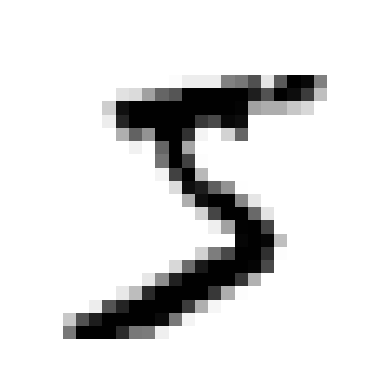

'5'

In [3]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)  # image_data는 보통 길이 784(=28×28)인 1차원 배열(벡터).
                                      # reshape(28, 28)은 그 벡터를 2차원 이미지 형태(28행 28열)로 바꾸는 것.

  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()
y[0]

데이터를 자세히 조사하기 전에 항상 테스트 세트를 만들고 따로 떼어놓아야 함.

fetch_openml()이 반환한 MNIST 데이터셋은 이미 훈련 세트(앞쪽 60,000개)와 테스트 세트(뒤쪽 10,000개)로 나뉘어있음

In [4]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

---
## 3.2 이진 분류기 훈련

5-감지기는 '5'와 '5아님' 두 개의 클래스를 구분할 수 있는 이진 분류기

In [5]:
y_train_5 = (y_train =='5') # 5는 True고. 다른 숫자는 모두 False
y_test_5 = (y_test =='5')

분류 모델을 하나 선택해서 훈련해보자.

- **확률적 경사 하강법 SDG**: 사이킷런의 SGDClassifier 클래스를 사용하며 매우 큰 데이터셋을 효율적으로 처리할 수 있다는 장점이 있음. 한번에 하나씩 훈련 샘플을 독립적으로 처리할 수 있음

In [6]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# 이 모델을 사용해 숫자 5의 이미지를 감지해보자면
sgd_clf.predict([some_digit])

# 값이 True가 나왔다면 이미지가 5를 나타낸다고 추측함.
# 해당 샘플에 대해서는 정확히 맞춤 !!

array([ True])

---
## 3.3 성능 측정

### 3.3.1 교차 검증을 사용한 정확도 측정

cross_val_score() 함수로 폴드가 3개인 k-폴드 교차 검증을 사용해 SGDClassifier 모델을 평가해보자.



In [7]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

모든 교차 검증 폴드에 대해 정확도가 95% 이상임 !!

모든 이미지를 가장 많이 등장하는 클래스로 분류하는 더미 분류기를 만들어 비교함

In [8]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# False가 출력됩니다. 즉, True로 예측된 것이 없습니다.
print(any(dummy_clf.predict(X_train)))

cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

False


array([0.90965, 0.90965, 0.90965])

정확도가 90% 이상으로 나옴! 이미지의 10% 정도만 숫자 5이기 때문에 무조건 '5아님'으로 예측하면 정확히 맞출 확률이 90%이다.

이 예제는 정확도를 분류기의 성능 측정 지표로 선호하지 않는 이유를 보여줌. 특히 불균형한 데이터셋을 다룰 때 더욱 그럼.

분류기의 성능을 평가하는 더 좋은 방법은 오차 행렬을 조사하는 것이다.

### 3.3.2 오차 행렬

오차 행렬의 기본 아이디어는 모든 A/B 쌍에 대해 클래스 A의 샘플이 클래스 B로 분류된 횟수를 세는 것이다.

예 ) 분류기가 숫자 8의 이미지를 0으로 잘못 분류한 횟수를 알고 싶다면 오차 행렬에서 8번 행의 0번 열을 보면 됨

오차 행렬을 만들려면 실제 타깃과 비교할 수 있도록 예측값을 만들어야 함. (테스트 세트로 만들 순 있지만 여기서 사용X)

→ cross_val_predict() 함수 사용

In [9]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

cross_val_predict() 함수는 k-폴드 교차 검증을 수행하지만 평가 점수를 반환하지 않고, 각 테스트 폴드에서 얻은 예측을 반환

 = 훈련 세트의 모든 샘플에 대해 깨끗한 예측을 얻게 됨 (깨끗==훈련하는 동안 보지 못했던 데이터에 대해 예측)


In [10]:
# confusion_matrix() 함수를 사용해 오차행렬을 만들자
# 타깃 클래스 (y_train_5)와 예측 클래스 (y_train_pred)를 넣고 호출하면 됨

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

오차 행렬의 행 = 실제 클래스, 열 = 예측한 클래스를 나타냄

이 행렬의 첫 번째 행은 '5 아님' 이미지(음성 클래스)에 대한 것으로 53892개를 '5 아님'으로 정확하게 분류했고(진짜 음성) 나머지 687개는 '5'라고 잘못 분류함 (거짓 양성)

두 번째 행은 '5' 이미지(양성 클래스)에 대한 것으로 1,891개를 '5 아님'으로 잘못 분류했고(거짓 음성 또는 2종오류) ㄴ아머지 3,530개를 정확히 '5'라고 분류함(진짜양성)

완벽한 분류기라면 진짜 양성과 진짜 음성만 가지고 있을 것이므로 오차행렬의 주대각성만 0이 아닌 값이 됨

In [12]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

**정밀도** : 오차행렬보다 조금 더 요약된 지표로 양성 예측의 정확도를 뜻한다.


$ 정밀도  = \frac{TP}{TP + FP} $

$TP$ = 진짜 양성의 수, $FP$ = 거짓 양성의 수

가장 간단한 방법은 제일 확신이 높은 샘플에 대해 양성 예측을 하고 나머지는 모두 음성 예측을 하는 분류기 →  양성 예측이 맞는다면 정밀도는 100%

하지만 이런 분류기는 다른 모든 양성 샘플을 무시하기에 유용하지 않음

**재현율**(=민감도,TPR) : 정밀도와 같이 사용하는 지표. 분류기가 정확하게 감지한 양성 샘플의 비율을 뜻함

$재현율 = \frac{TP}{TP + FN}$

$FN$ = 거짓 음성의 수






### 3.3.3 정밀도와 재현율

사이킷런은 정밀도와 재현율을 포함하여 분류기의 지표를 계산하는 여러 함수를 제공

In [13]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred) # == 3530 / (687 + 3530)


0.8370879772350012

In [14]:
recall_score(y_train_5, y_train_pred) # == 3530 / (1891 + 3530)

0.6511713705958311

'5-감지기'가 정확도에서 봤을 떄만큼 좋진 않음

5로 판별된 이미지 중 83.7%만 정확하고 전체 숫자 5에서 65.1%만 감지함

**$F_1$점수** : 정밀도와 재현율의 조화평균(보통의 평균보다 낮은 값에 비중을 더 둠)

$ F_1 score = \frac{2}{\frac{1}{정밀도} + \frac{1}{재현율}} = 2 \times \frac{정밀도 × 재현율}{정밀도 + 재현율} = \frac{TP}{TP + \frac{FN + FP}{2}}$

f_